🔥 Warming up the CPU and OS RAM Cache...

🚀 Starting High-Precision Benchmark...

Running with 1 thread(s)... best time: 11.030s (out of 3 runs)
Running with 2 thread(s)... best time: 6.967s (out of 3 runs)
Running with 3 thread(s)... best time: 5.468s (out of 3 runs)
Running with 4 thread(s)... best time: 4.090s (out of 3 runs)
Running with 5 thread(s)... best time: 4.246s (out of 3 runs)
Running with 6 thread(s)... best time: 3.385s (out of 3 runs)
Running with 8 thread(s)... best time: 3.070s (out of 3 runs)
Running with 10 thread(s)... best time: 2.735s (out of 3 runs)
Running with 12 thread(s)... best time: 2.614s (out of 3 runs)

📊 Benchmarks complete! Generating graph...
✅ Graph saved successfully as 'scaling_graph_warmed_up.png'!


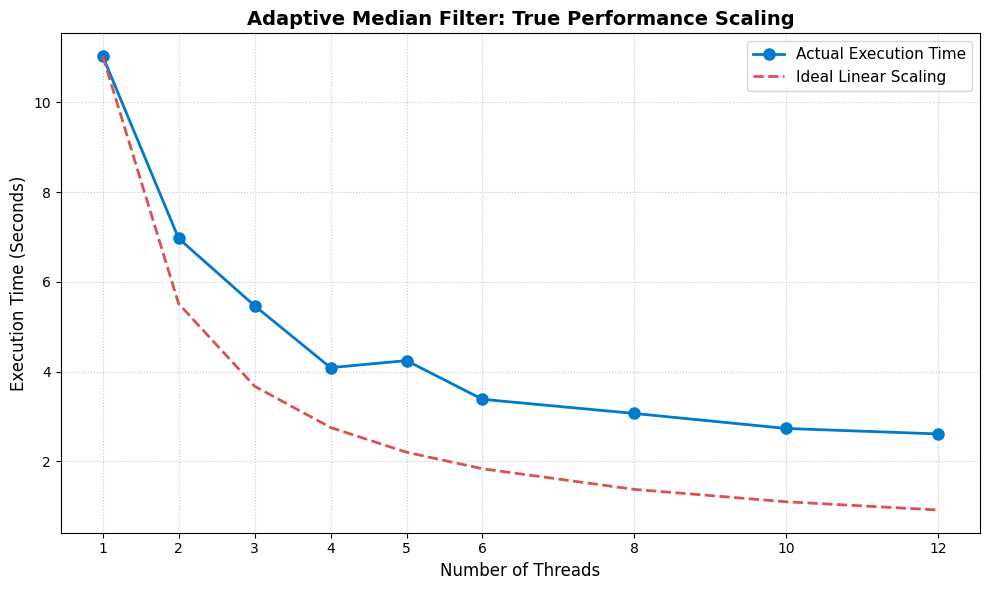

In [ ]:
import subprocess
import time
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
PROGRAM_CMD = ['./../denoise', '../imgs/noisy_test.ppm', 'output.ppm']
THREAD_COUNTS = [1, 2, 3, 4, 5, 6,7, 8,9, 10,11, 12]
RUNS_PER_TEST = 3  # Run each test 3 times to filter out OS noise
# ---------------------

print("🔥 Warming up the CPU and OS RAM Cache...")
# This run is NOT timed. It just forces the file into memory and wakes up the CPU.
subprocess.run(PROGRAM_CMD + ['1'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

execution_times = []

print("\n🚀 Starting High-Precision Benchmark...\n")

for threads in THREAD_COUNTS:
    print(f"Running with {threads} thread(s)...", end="", flush=True)
    
    times_for_this_thread = []
    
    for _ in range(RUNS_PER_TEST):
        cmd = PROGRAM_CMD + [str(threads)]
        
        start_time = time.perf_counter()
        subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        end_time = time.perf_counter()
        
        times_for_this_thread.append(end_time - start_time)
    
    # Take the MINIMUM time. This is the run where the OS interrupted us the least!
    best_time = min(times_for_this_thread)
    execution_times.append(best_time)
    
    print(f" best time: {best_time:.3f}s (out of {RUNS_PER_TEST} runs)")

print("\n📊 Benchmarks complete! Generating graph...")

# Calculate ideal scaling based on the completely warmed-up 1-thread time
base_time = execution_times[0]
ideal_times = [base_time / t for t in THREAD_COUNTS]

# Draw the graph
plt.figure(figsize=(10, 6))
plt.plot(THREAD_COUNTS, execution_times, marker='o', markersize=8, 
         linestyle='-', color='#007acc', linewidth=2, label='Actual Execution Time')
plt.plot(THREAD_COUNTS, ideal_times, marker='', 
         linestyle='--', color='#d9534f', linewidth=2, label='Ideal Linear Scaling')

plt.title('Adaptive Median Filter: True Performance Scaling', fontsize=14, fontweight='bold')
plt.xlabel('Number of Threads', fontsize=12)
plt.ylabel('Execution Time (Seconds)', fontsize=12)
plt.xticks(THREAD_COUNTS)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

plt.tight_layout()
plt.savefig('scaling_graph_warmed_up.png', dpi=300)
print("✅ Graph saved successfully as 'scaling_graph_warmed_up.png'!")